<a href="https://www.kaggle.com/code/omborse771924/spotify-artist-streaming-analysis-92-accuracy?scriptVersionId=343995556" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yogeshm01/spotify-artist-streaming-analytics-20152025/spotify_data_processed.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yogeshm01/spotify-artist-streaming-analytics-20152025/spotify_data_processed.csv')

In [3]:
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,...,Medium,Quiet,A,Minor,False,2,False,9.472782,0.445,1
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,...,Medium,Moderate,C,Minor,True,2,False,6.908755,0.450,3
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,...,Medium,Quiet,G#,Major,True,1,False,6.908755,0.710,2
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,...,Medium,Quiet,C#,Major,False,4,False,6.908755,0.880,4
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,...,Medium,Moderate,A#,Minor,False,3,False,7.601402,0.460,2


In [4]:
df.info

<bound method DataFrame.info of                track_id                             track_name  \
0      TRK-BEBD53DA84E1                        Agent every (0)   
1      TRK-6A32496762D7                          Night respond   
2      TRK-47AA7523463E                 Future choice whatever   
3      TRK-25ADA22E3B06                    Bad fall pick those   
4      TRK-9245F2AD996A                                Husband   
...                 ...                                    ...   
84995  TRK-462F0DB0EB74                     Address fire large   
84996  TRK-7AB4B28EC4C4  Agent section road individual certain   
84997  TRK-4E7FAE07FBEC                              Attention   
84998  TRK-F86B054551B6                        You act century   
84999  TRK-1AFF404AA899                       Republican focus   

          artist_name         album_name release_date    genre  duration_ms  \
0         Noah Rhodes  Beautiful instead   2016-04-01      Pop       234194   
1       Jennifer 

In [5]:
df.isnull

<bound method DataFrame.isnull of                track_id                             track_name  \
0      TRK-BEBD53DA84E1                        Agent every (0)   
1      TRK-6A32496762D7                          Night respond   
2      TRK-47AA7523463E                 Future choice whatever   
3      TRK-25ADA22E3B06                    Bad fall pick those   
4      TRK-9245F2AD996A                                Husband   
...                 ...                                    ...   
84995  TRK-462F0DB0EB74                     Address fire large   
84996  TRK-7AB4B28EC4C4  Agent section road individual certain   
84997  TRK-4E7FAE07FBEC                              Attention   
84998  TRK-F86B054551B6                        You act century   
84999  TRK-1AFF404AA899                       Republican focus   

          artist_name         album_name release_date    genre  duration_ms  \
0         Noah Rhodes  Beautiful instead   2016-04-01      Pop       234194   
1       Jennife

In [6]:
df.isnull().sum()

track_id               0
track_name             0
artist_name            0
album_name             0
release_date           0
genre                  0
duration_ms            0
popularity             0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
instrumentalness       0
tempo                  0
stream_count           0
country                0
explicit               0
label                  0
release_year           0
release_month          0
release_day_of_week    0
duration_minutes       0
popularity_category    0
loudness_category      0
key_name               0
mode_name              0
is_explicit_bool       0
release_quarter        0
is_weekend_release     0
log_stream_count       0
upbeat_score           0
artist_track_count     0
dtype: int64

In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
84995    False
84996    False
84997    False
84998    False
84999    False
Length: 85000, dtype: bool

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_date',
       'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count',
       'country', 'explicit', 'label', 'release_year', 'release_month',
       'release_day_of_week', 'duration_minutes', 'popularity_category',
       'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool',
       'release_quarter', 'is_weekend_release', 'log_stream_count',
       'upbeat_score', 'artist_track_count'],
      dtype='object')

## EDA

DATASET INFORMATION
Rows    : 85000
Columns : 33

Columns:
['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label', 'release_year', 'release_month', 'release_day_of_week', 'duration_minutes', 'popularity_category', 'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool', 'release_quarter', 'is_weekend_release', 'log_stream_count', 'upbeat_score', 'artist_track_count']

Numerical Columns:
['duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'explicit', 'release_year', 'release_month', 'duration_minutes', 'release_quarter', 'log_stream_count', 'upbeat_score', 'artist_track_count']


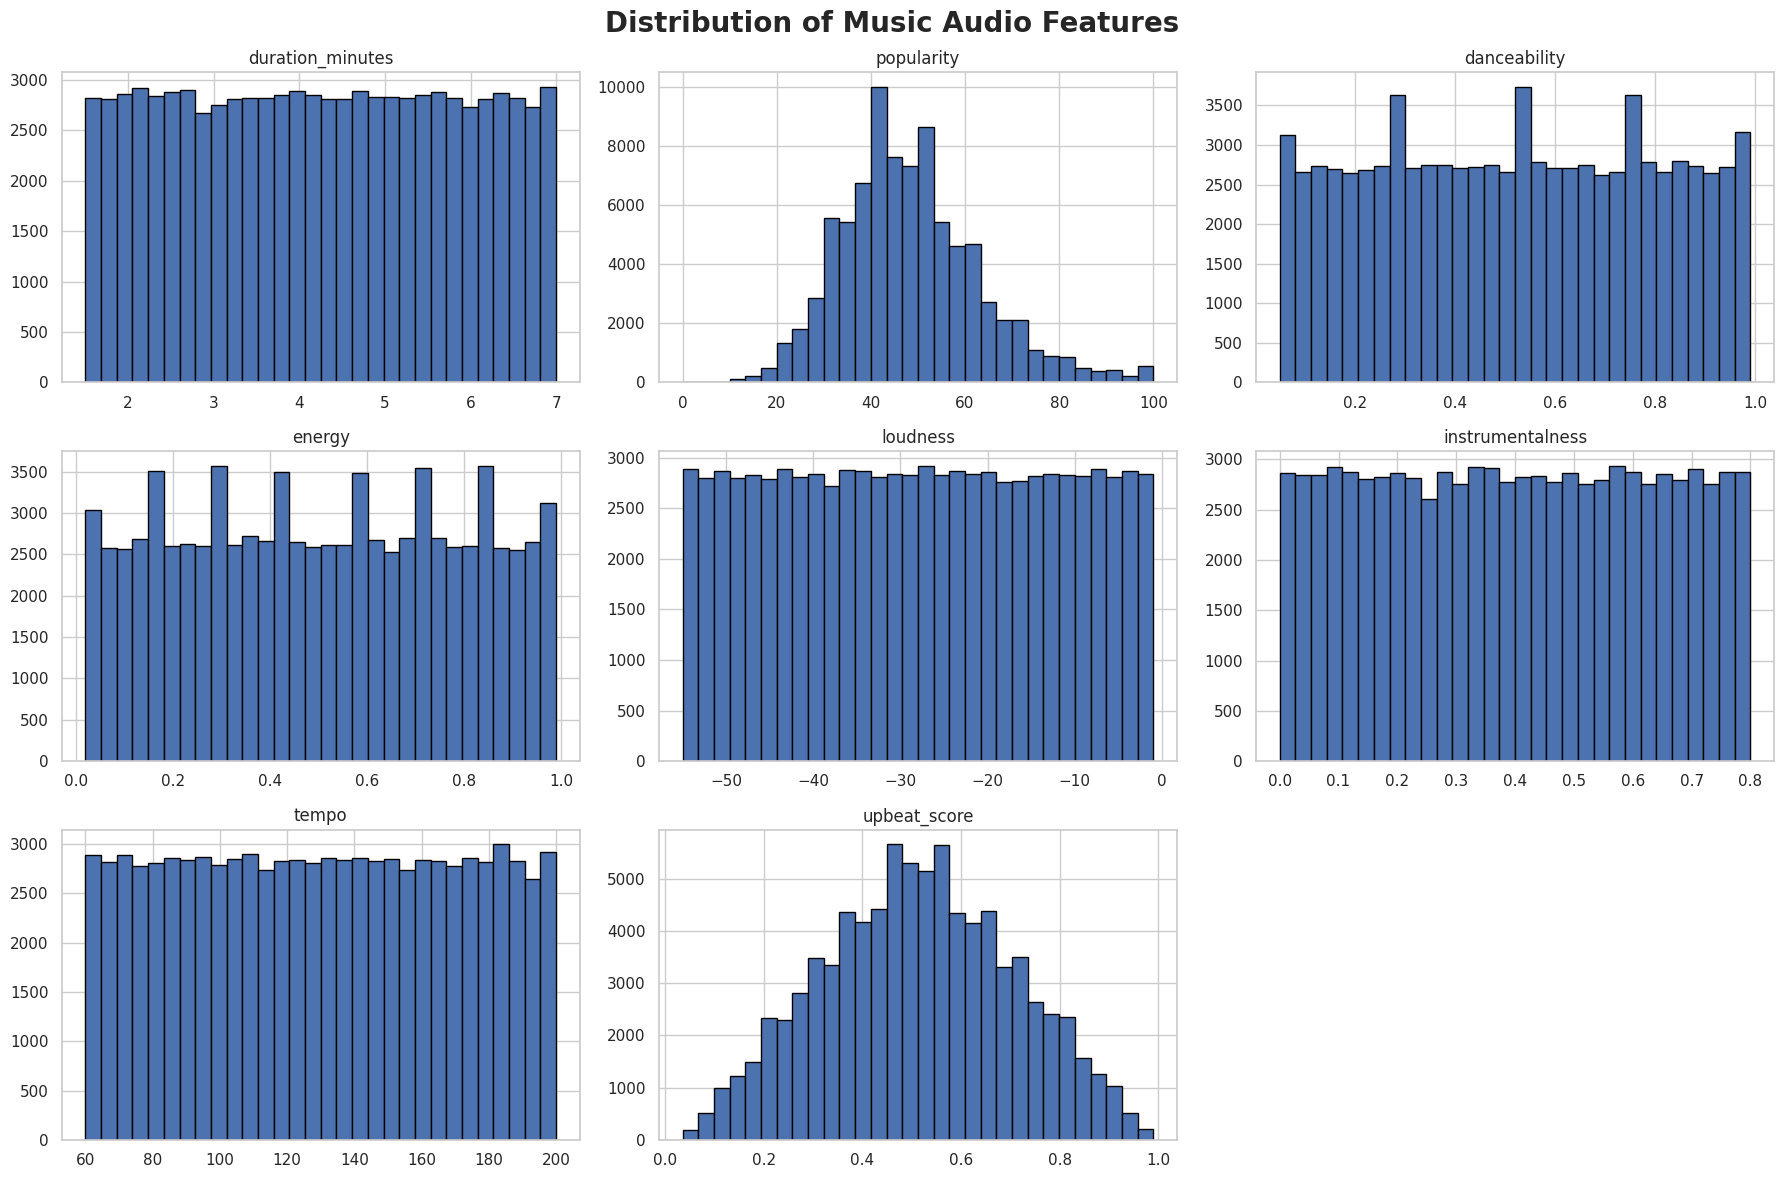

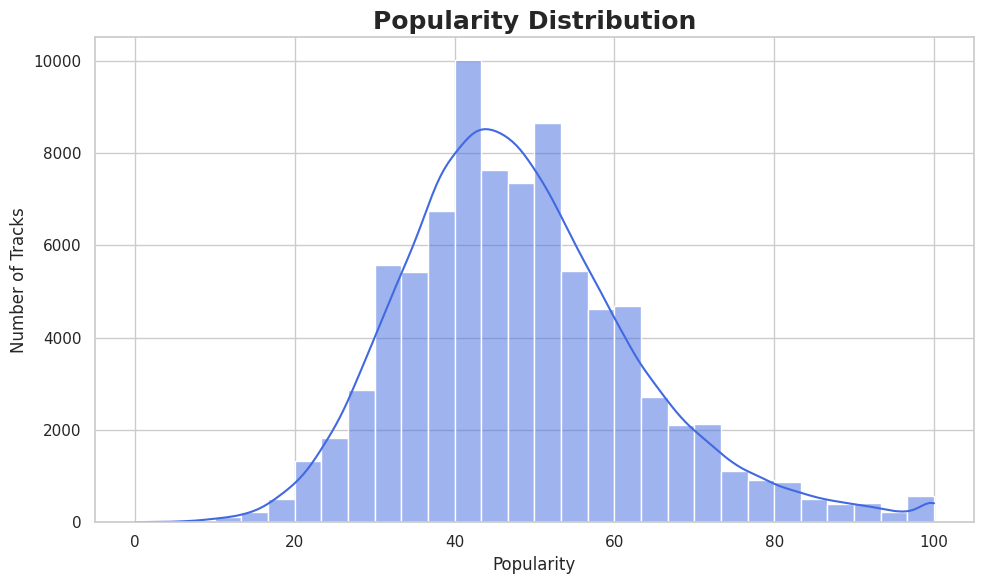

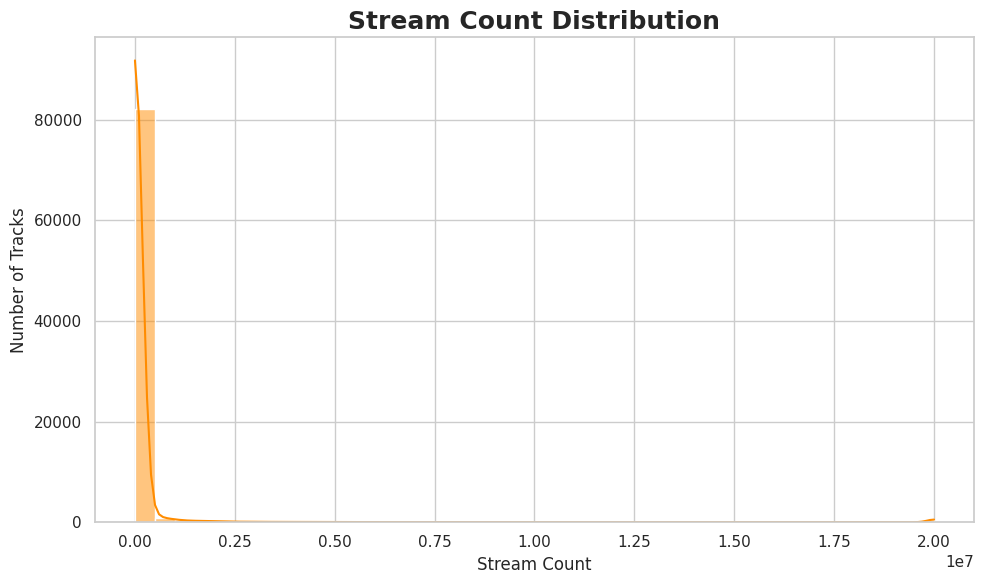

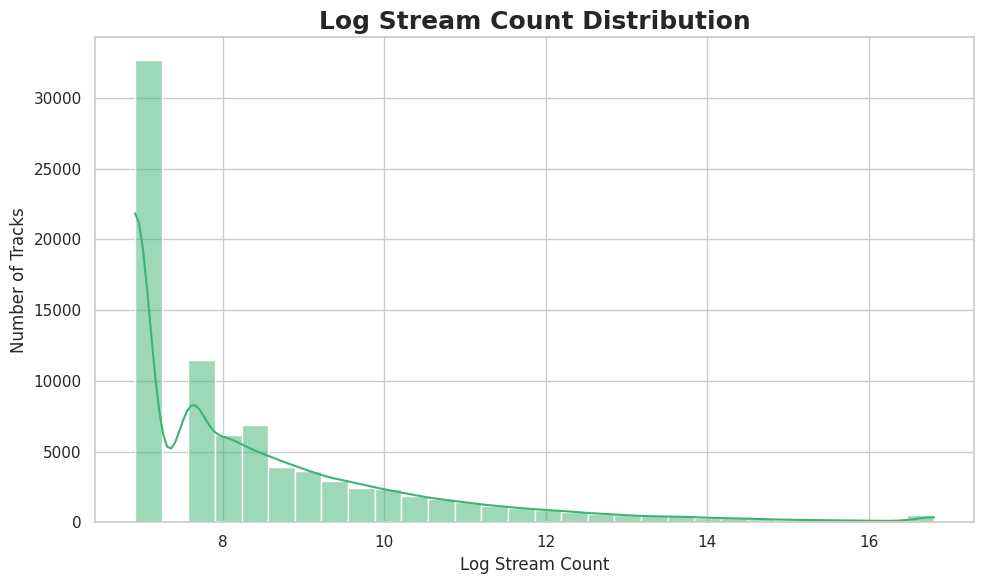

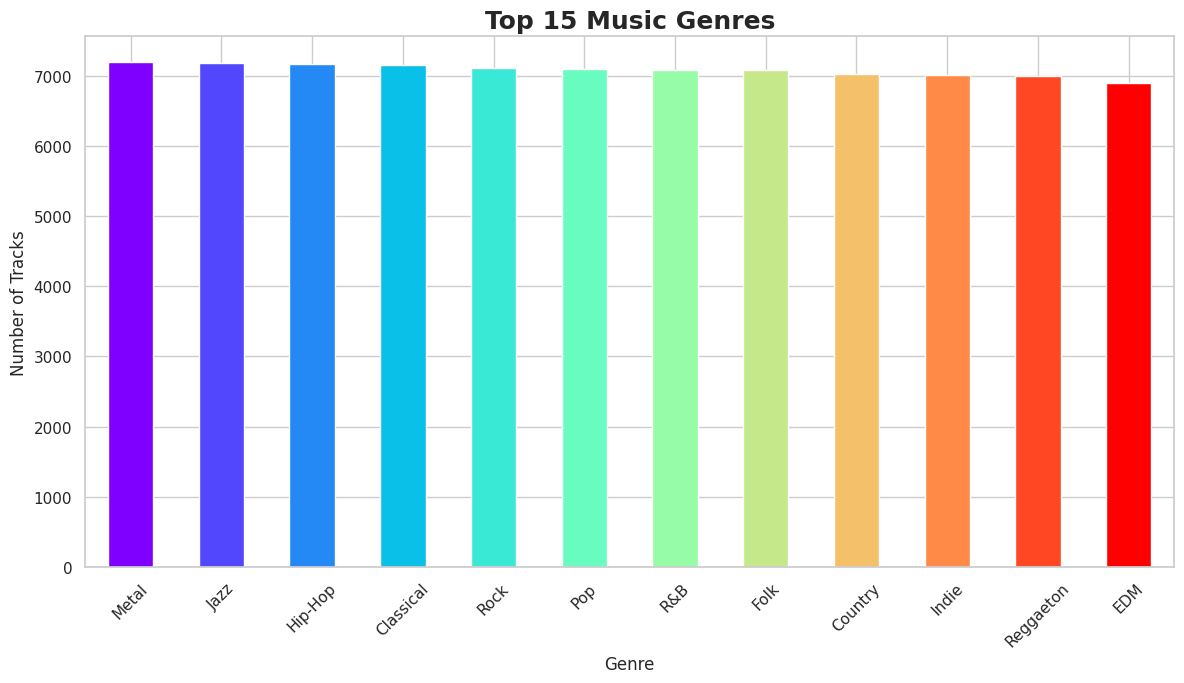

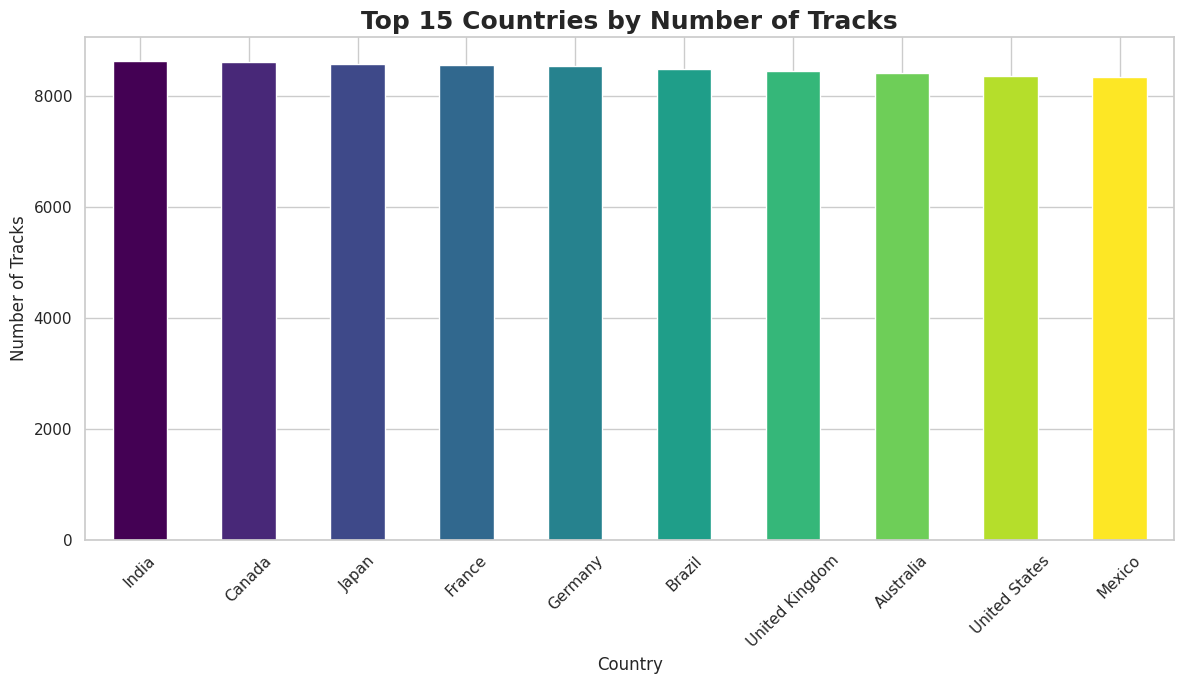

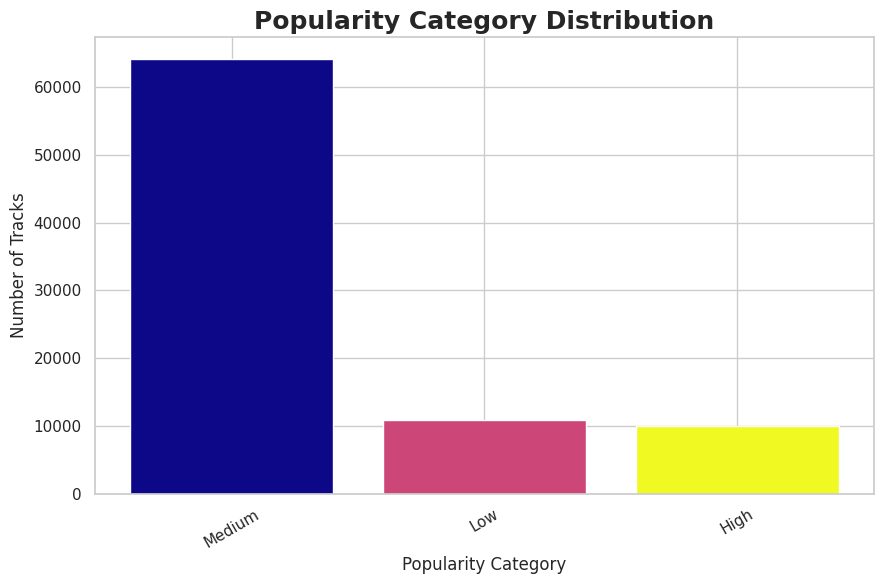

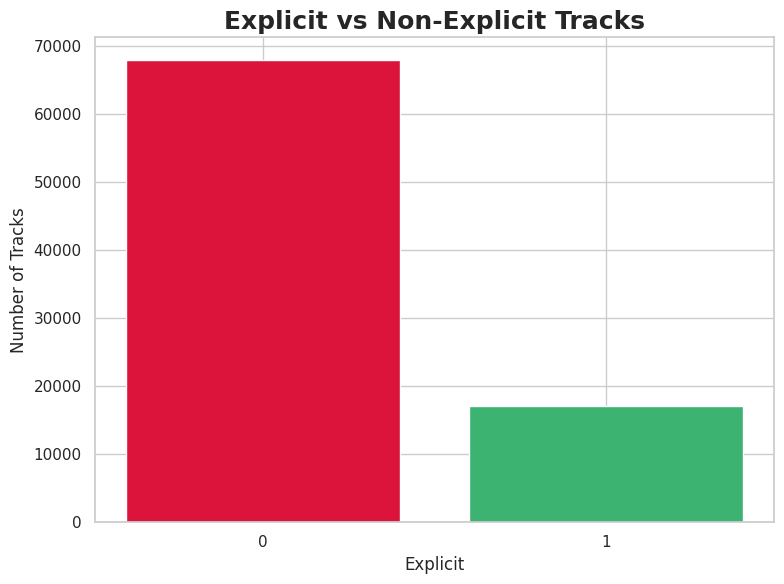

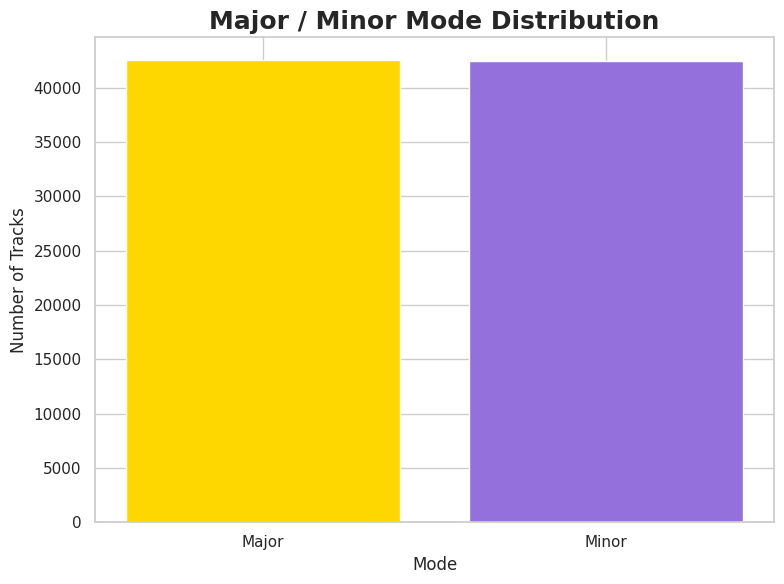

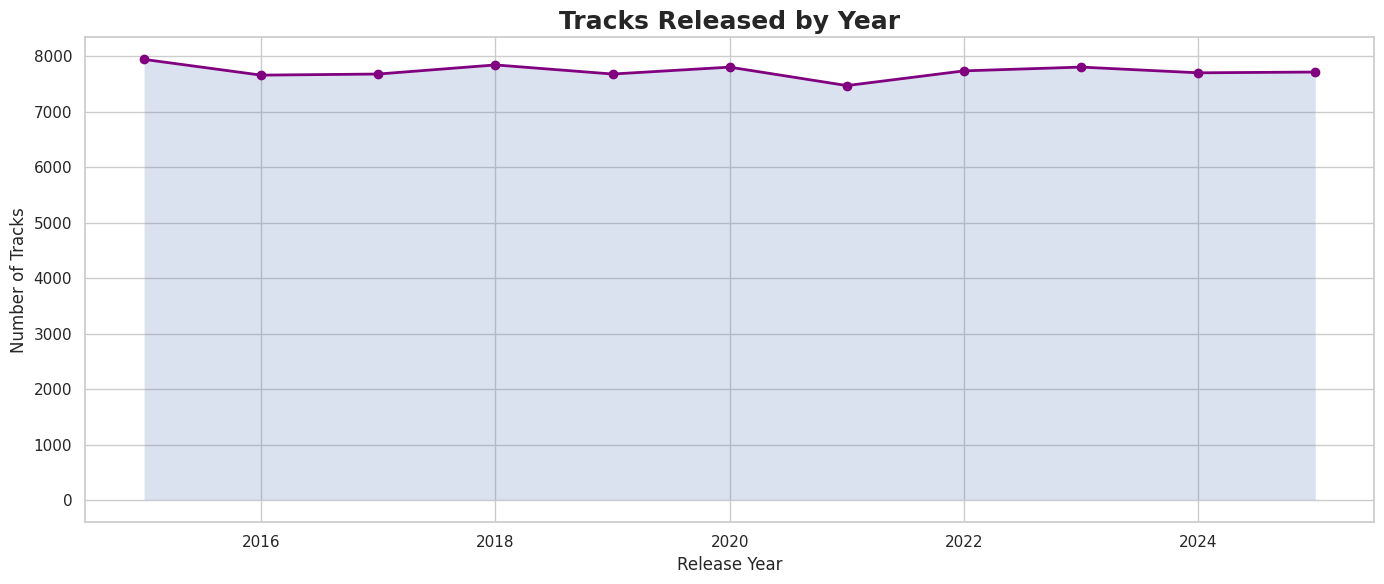

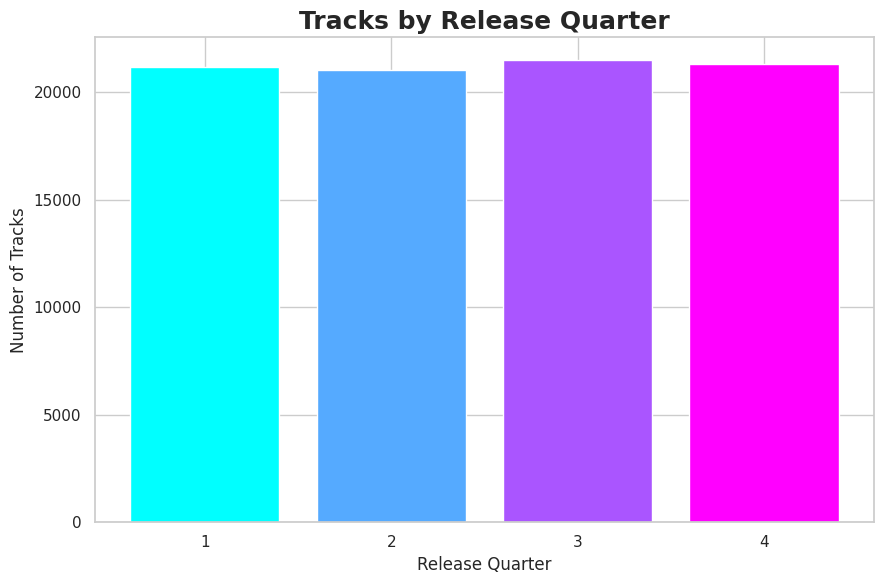

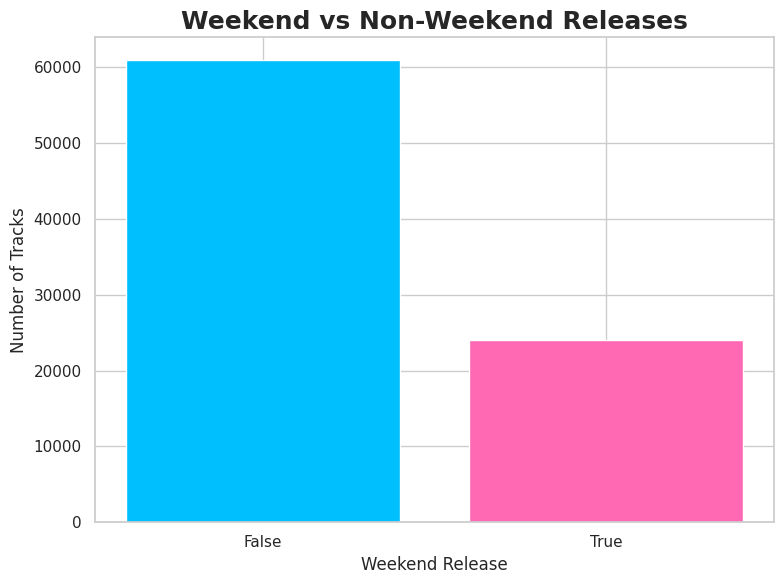

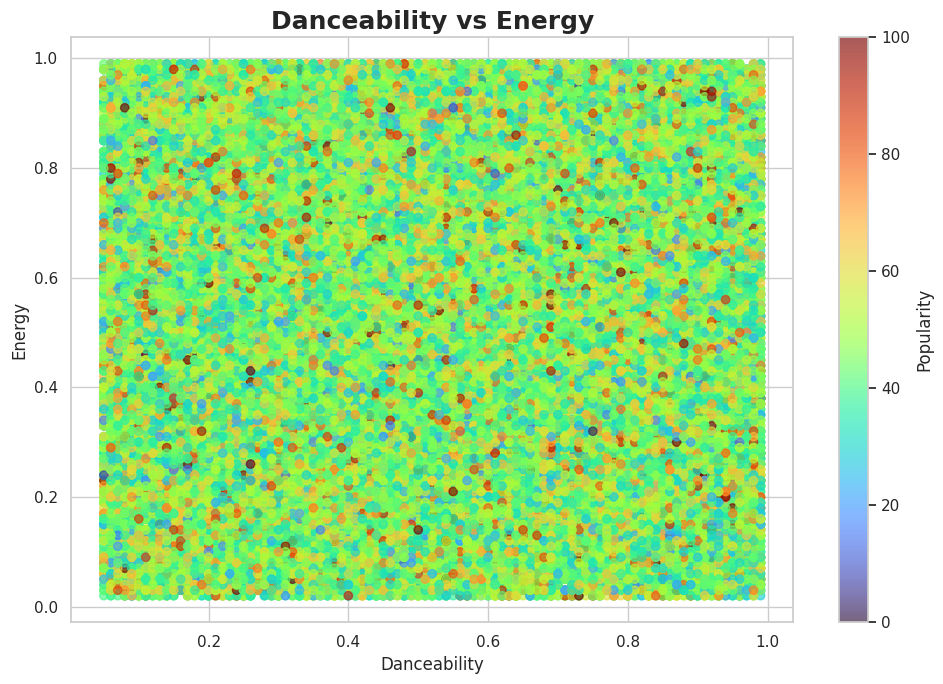

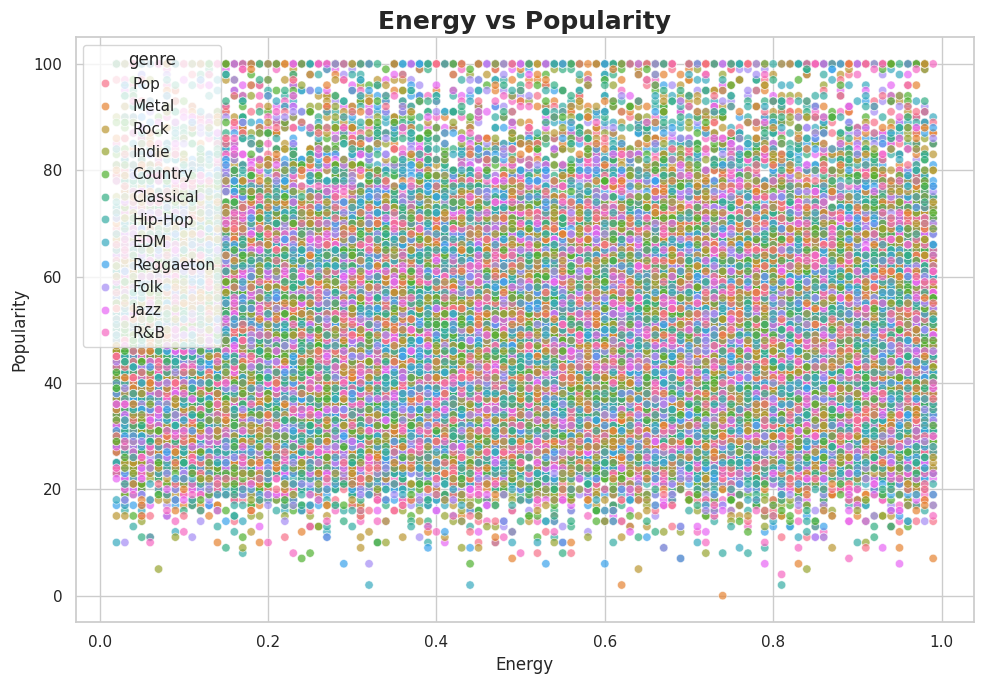

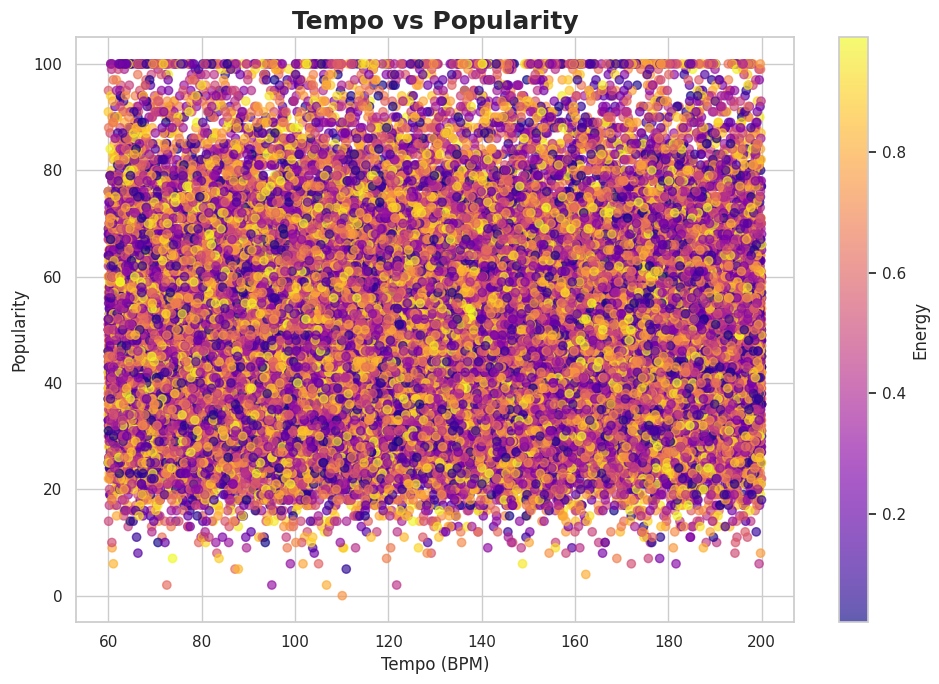

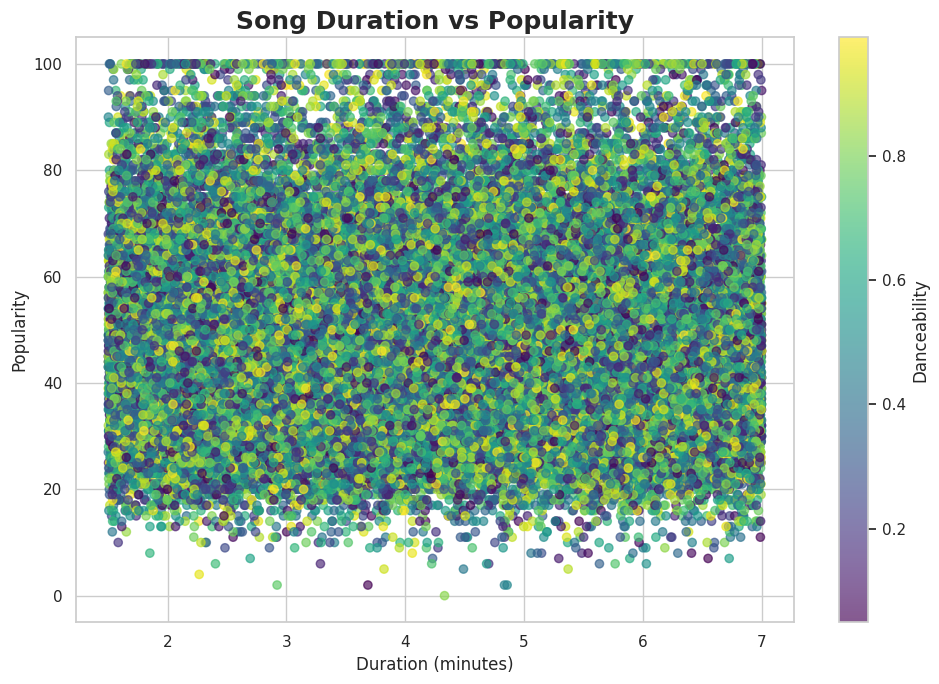

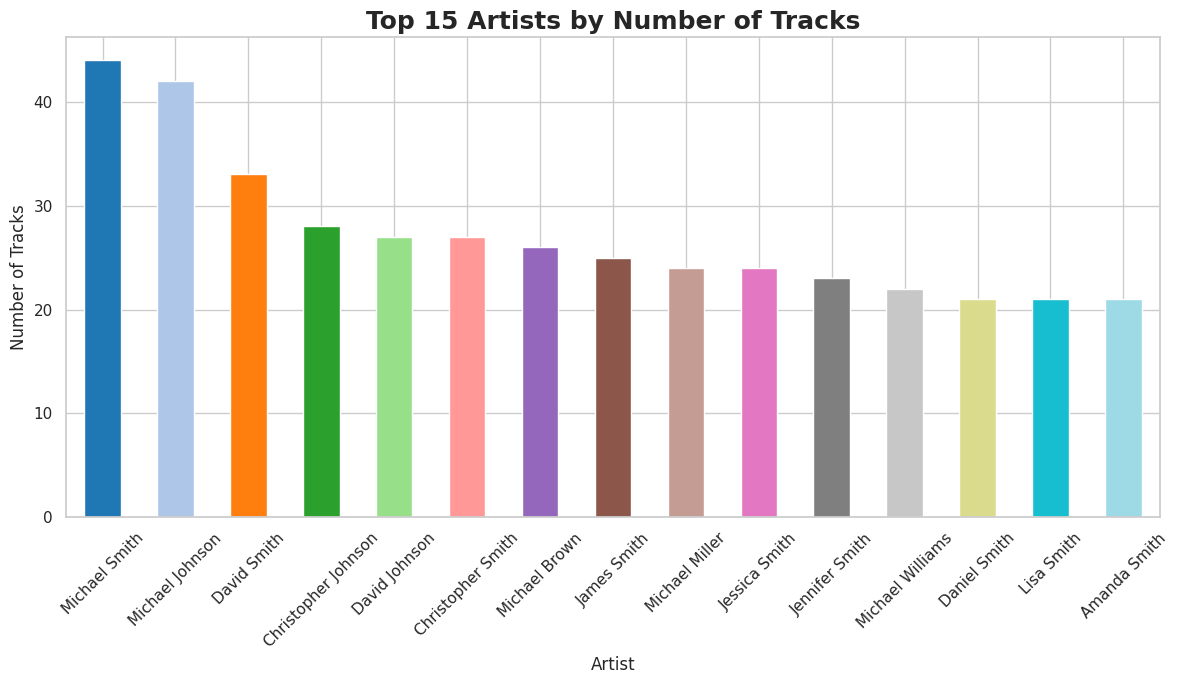

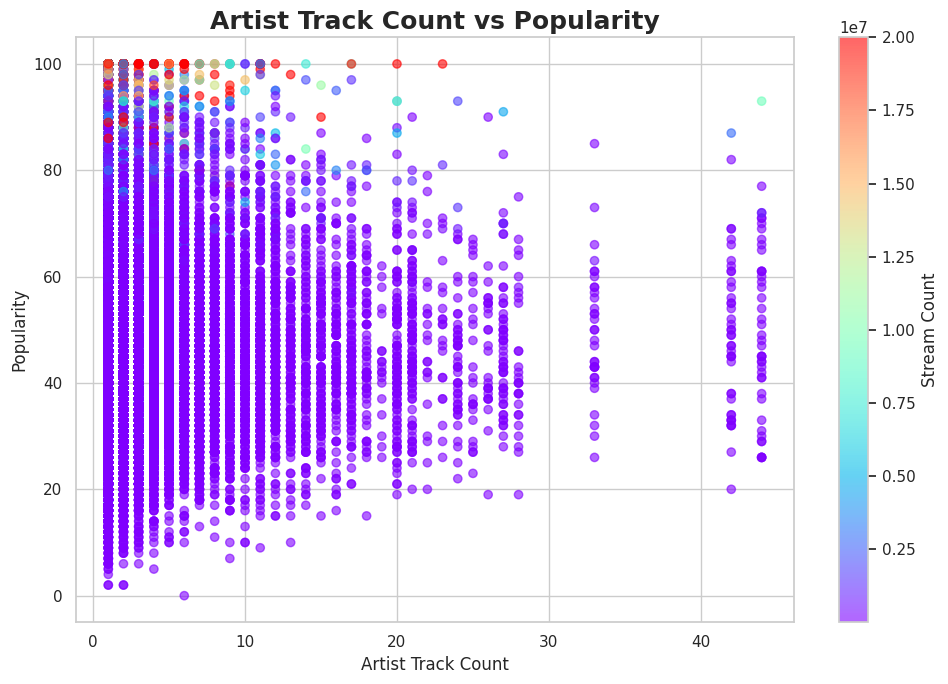

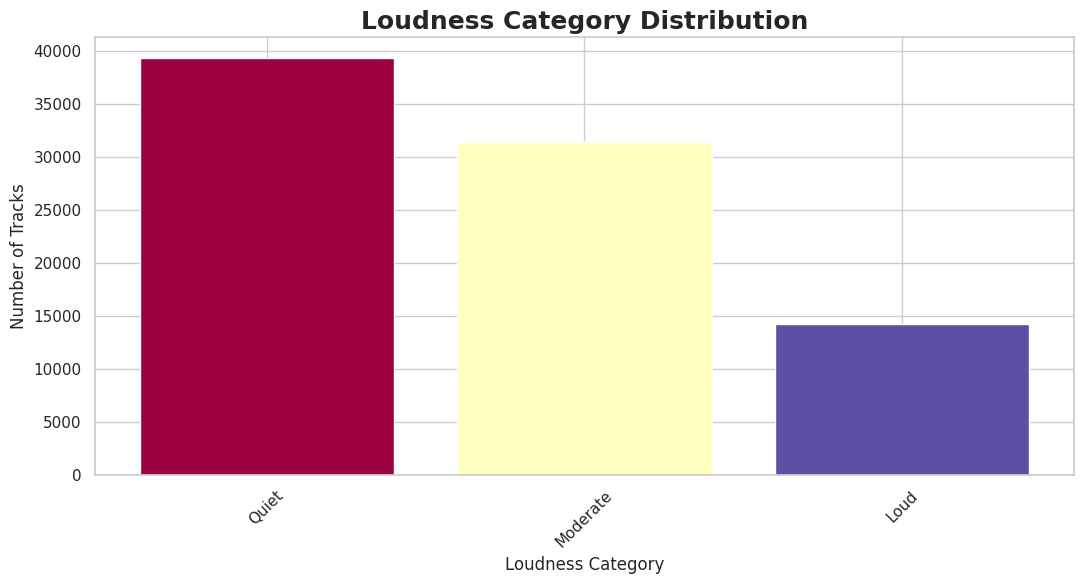

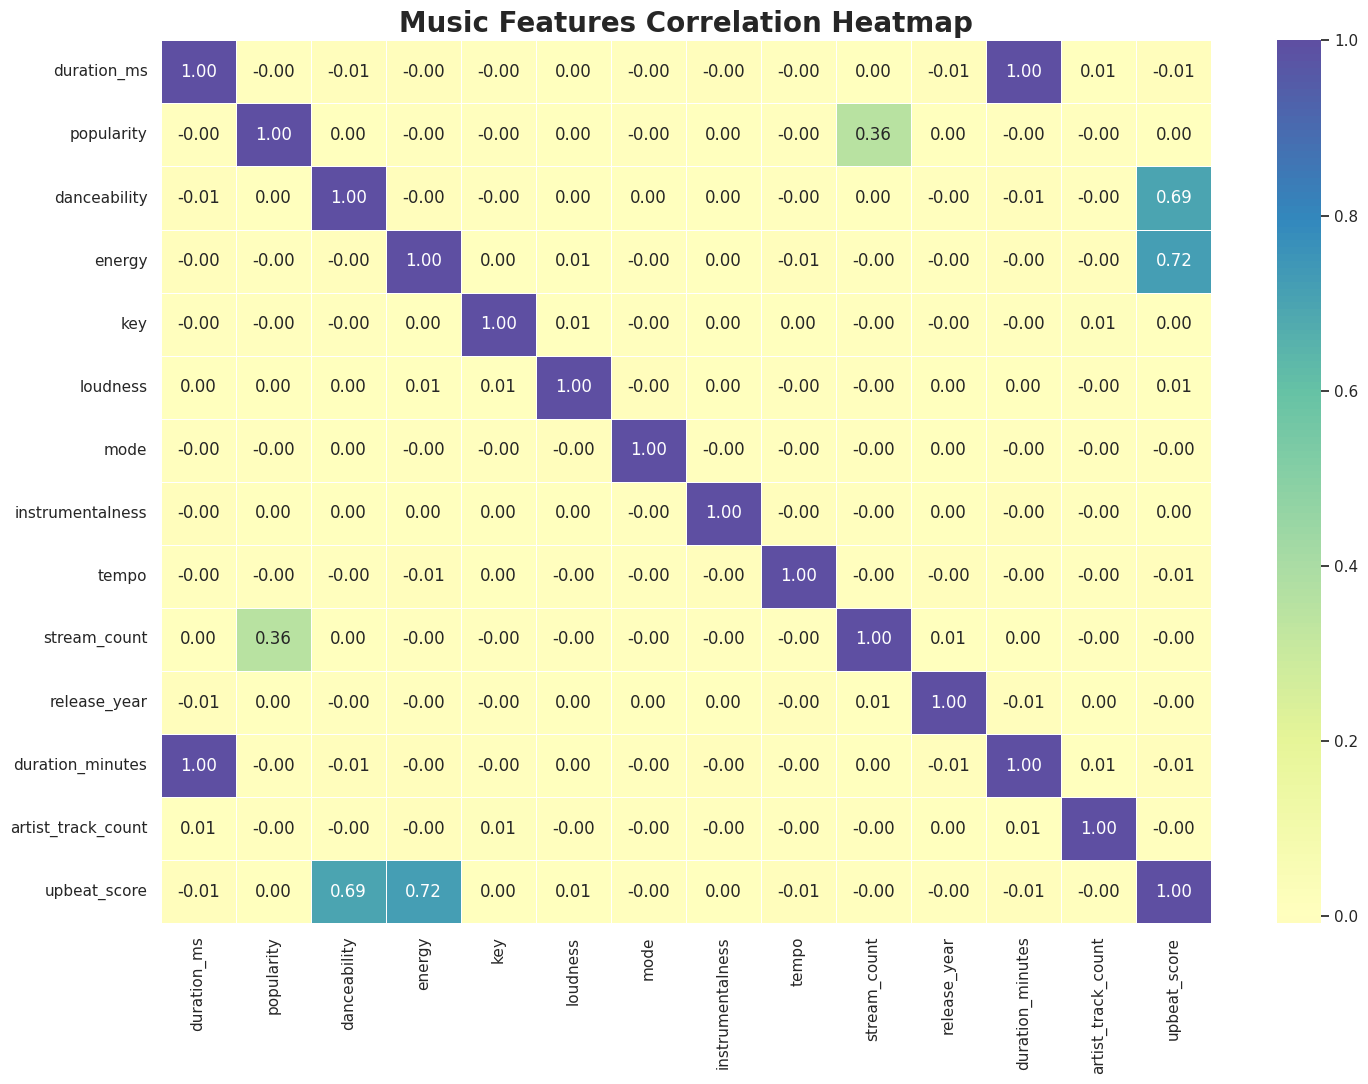

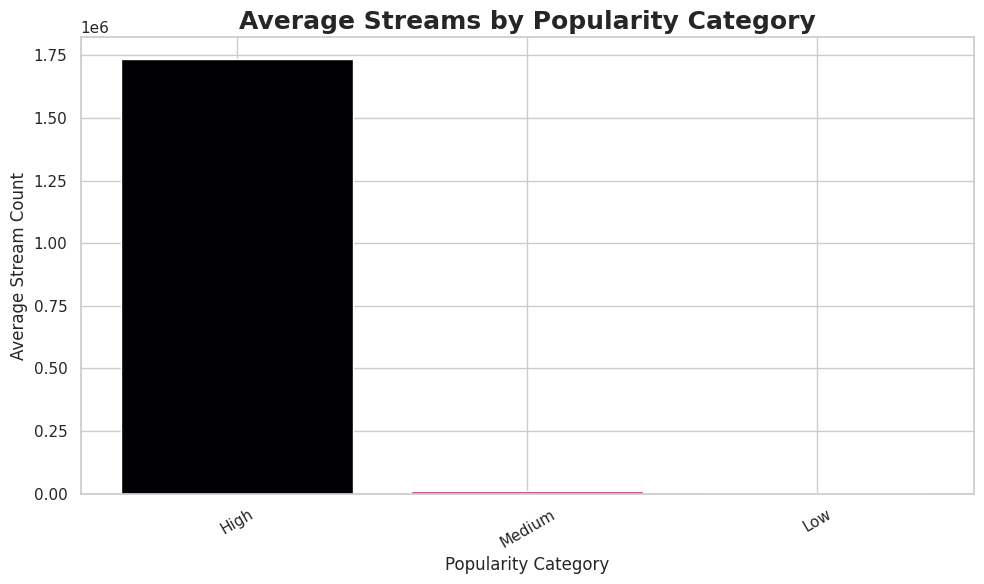

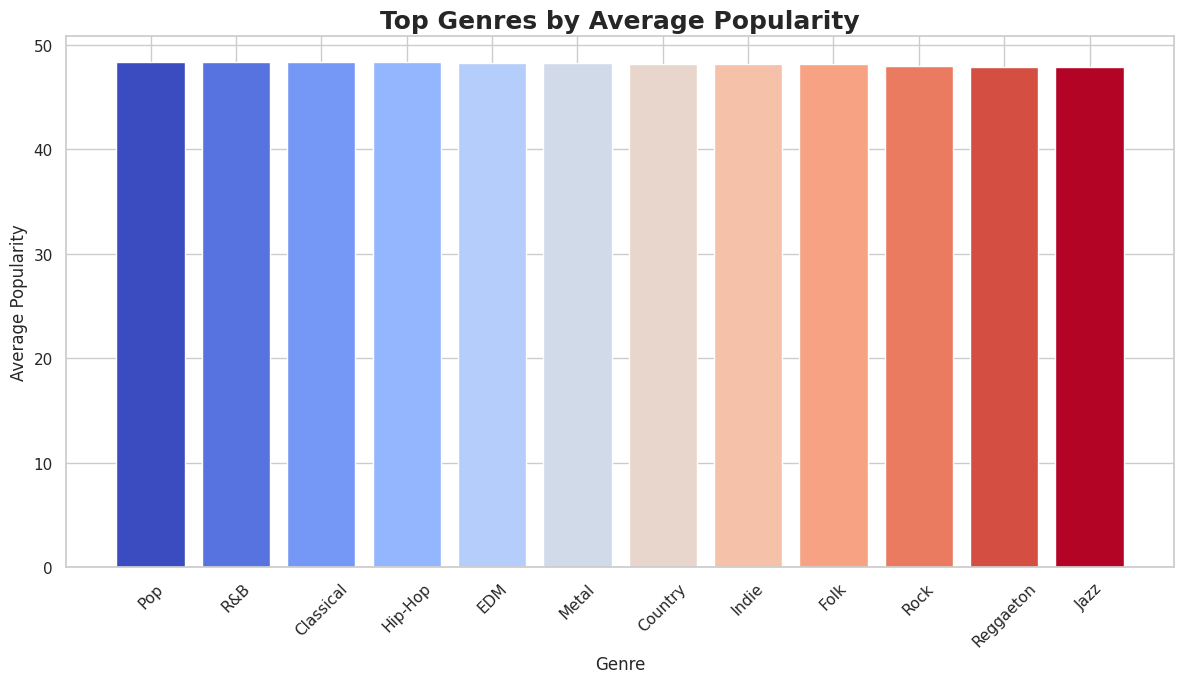


ALL MUSIC VISUALIZATIONS COMPLETED SUCCESSFULLY!


In [10]:
# ==========================================================
# MUSIC DATASET - COLORFUL VISUALIZATION
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Copy dataset
# ----------------------------------------------------------
data = df.copy()

sns.set_theme(style="whitegrid")

# ==========================================================
# 1. DATASET INFORMATION
# ==========================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

print("\nColumns:")
print(data.columns.tolist())


# ==========================================================
# 2. NUMERICAL COLUMNS
# ==========================================================

numeric_cols = data.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical Columns:")
print(numeric_cols)


# ==========================================================
# 3. HISTOGRAMS - AUDIO FEATURES
# ==========================================================

audio_cols = [
    "duration_minutes",
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "instrumentalness",
    "tempo",
    "upbeat_score"
]

audio_cols = [
    col for col in audio_cols
    if col in data.columns
]

if len(audio_cols) > 0:

    data[audio_cols].hist(
        figsize=(18, 12),
        bins=30,
        edgecolor="black"
    )

    plt.suptitle(
        "Distribution of Music Audio Features",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ==========================================================
# 4. POPULARITY DISTRIBUTION
# ==========================================================

if "popularity" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data["popularity"],
        bins=30,
        kde=True,
        color="royalblue"
    )

    plt.title(
        "Popularity Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Popularity")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 5. STREAM COUNT DISTRIBUTION
# ==========================================================

if "stream_count" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data["stream_count"],
        bins=40,
        kde=True,
        color="darkorange"
    )

    plt.title(
        "Stream Count Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Stream Count")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 6. LOG STREAM COUNT
# ==========================================================

if "log_stream_count" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data["log_stream_count"],
        bins=30,
        kde=True,
        color="mediumseagreen"
    )

    plt.title(
        "Log Stream Count Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Log Stream Count")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 7. GENRE DISTRIBUTION
# ==========================================================

if "genre" in data.columns:

    genre_counts = (
        data["genre"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    genre_counts.plot(
        kind="bar",
        color=plt.cm.rainbow(
            np.linspace(
                0,
                1,
                len(genre_counts)
            )
        )
    )

    plt.title(
        "Top 15 Music Genres",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Genre")
    plt.ylabel("Number of Tracks")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ==========================================================
# 8. COUNTRY DISTRIBUTION
# ==========================================================

if "country" in data.columns:

    country_counts = (
        data["country"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    country_counts.plot(
        kind="bar",
        color=plt.cm.viridis(
            np.linspace(
                0,
                1,
                len(country_counts)
            )
        )
    )

    plt.title(
        "Top 15 Countries by Number of Tracks",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Country")
    plt.ylabel("Number of Tracks")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ==========================================================
# 9. POPULARITY CATEGORY
# ==========================================================

if "popularity_category" in data.columns:

    counts = (
        data["popularity_category"]
        .value_counts()
    )

    plt.figure(figsize=(9, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.plasma(
            np.linspace(
                0,
                1,
                len(counts)
            )
        )
    )

    plt.title(
        "Popularity Category Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Popularity Category")
    plt.ylabel("Number of Tracks")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ==========================================================
# 10. EXPLICIT VS NON-EXPLICIT
# ==========================================================

if "explicit" in data.columns:

    counts = (
        data["explicit"]
        .value_counts()
    )

    plt.figure(figsize=(8, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=[
            "crimson",
            "mediumseagreen"
        ][:len(counts)]
    )

    plt.title(
        "Explicit vs Non-Explicit Tracks",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Explicit")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 11. MODE DISTRIBUTION
# ==========================================================

if "mode_name" in data.columns:

    counts = (
        data["mode_name"]
        .value_counts()
    )

    plt.figure(figsize=(8, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=[
            "gold",
            "mediumpurple",
            "turquoise",
            "coral"
        ][:len(counts)]
    )

    plt.title(
        "Major / Minor Mode Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Mode")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 12. RELEASE YEAR DISTRIBUTION
# ==========================================================

if "release_year" in data.columns:

    year_counts = (
        data["release_year"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        year_counts.index,
        year_counts.values,
        marker="o",
        linewidth=2,
        color="purple"
    )

    plt.fill_between(
        year_counts.index,
        year_counts.values,
        alpha=0.2
    )

    plt.title(
        "Tracks Released by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Release Year")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 13. RELEASE QUARTER
# ==========================================================

if "release_quarter" in data.columns:

    counts = (
        data["release_quarter"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(9, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.cool(
            np.linspace(
                0,
                1,
                len(counts)
            )
        )
    )

    plt.title(
        "Tracks by Release Quarter",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Release Quarter")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 14. WEEKEND RELEASE
# ==========================================================

if "is_weekend_release" in data.columns:

    counts = (
        data["is_weekend_release"]
        .value_counts()
    )

    plt.figure(figsize=(8, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=[
            "deepskyblue",
            "hotpink"
        ][:len(counts)]
    )

    plt.title(
        "Weekend vs Non-Weekend Releases",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Weekend Release")
    plt.ylabel("Number of Tracks")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 15. DANCEABILITY VS ENERGY
# ==========================================================

if (
    "danceability" in data.columns
    and
    "energy" in data.columns
):

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        data["danceability"],
        data["energy"],
        c=data["popularity"]
        if "popularity" in data.columns
        else None,
        cmap="turbo",
        alpha=0.65
    )

    if "popularity" in data.columns:
        plt.colorbar(
            scatter,
            label="Popularity"
        )

    plt.title(
        "Danceability vs Energy",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Danceability")
    plt.ylabel("Energy")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 16. ENERGY VS POPULARITY
# ==========================================================

if (
    "energy" in data.columns
    and
    "popularity" in data.columns
):

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=data,
        x="energy",
        y="popularity",
        hue="genre"
        if "genre" in data.columns
        else None,
        palette="husl",
        alpha=0.7
    )

    plt.title(
        "Energy vs Popularity",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Energy")
    plt.ylabel("Popularity")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 17. TEMPO VS POPULARITY
# ==========================================================

if (
    "tempo" in data.columns
    and
    "popularity" in data.columns
):

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        data["tempo"],
        data["popularity"],
        c=data["energy"]
        if "energy" in data.columns
        else None,
        cmap="plasma",
        alpha=0.65
    )

    if "energy" in data.columns:

        plt.colorbar(
            scatter,
            label="Energy"
        )

    plt.title(
        "Tempo vs Popularity",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Tempo (BPM)")
    plt.ylabel("Popularity")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 18. DURATION VS POPULARITY
# ==========================================================

if (
    "duration_minutes" in data.columns
    and
    "popularity" in data.columns
):

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        data["duration_minutes"],
        data["popularity"],
        c=data["danceability"]
        if "danceability" in data.columns
        else None,
        cmap="viridis",
        alpha=0.65
    )

    if "danceability" in data.columns:

        plt.colorbar(
            scatter,
            label="Danceability"
        )

    plt.title(
        "Song Duration vs Popularity",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Duration (minutes)")
    plt.ylabel("Popularity")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 19. TOP ARTISTS
# ==========================================================

if "artist_name" in data.columns:

    artist_counts = (
        data["artist_name"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    artist_counts.plot(
        kind="bar",
        color=plt.cm.tab20(
            np.linspace(
                0,
                1,
                len(artist_counts)
            )
        )
    )

    plt.title(
        "Top 15 Artists by Number of Tracks",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Artist")
    plt.ylabel("Number of Tracks")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ==========================================================
# 20. ARTIST TRACK COUNT VS POPULARITY
# ==========================================================

if (
    "artist_track_count" in data.columns
    and
    "popularity" in data.columns
):

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        data["artist_track_count"],
        data["popularity"],
        c=data["stream_count"]
        if "stream_count" in data.columns
        else None,
        cmap="rainbow",
        alpha=0.6
    )

    if "stream_count" in data.columns:

        plt.colorbar(
            scatter,
            label="Stream Count"
        )

    plt.title(
        "Artist Track Count vs Popularity",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Artist Track Count")
    plt.ylabel("Popularity")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 21. LOUDNESS CATEGORY
# ==========================================================

if "loudness_category" in data.columns:

    counts = (
        data["loudness_category"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(11, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.Spectral(
            np.linspace(
                0,
                1,
                len(counts)
            )
        )
    )

    plt.title(
        "Loudness Category Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Loudness Category")
    plt.ylabel("Number of Tracks")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ==========================================================
# 22. CORRELATION HEATMAP
# ==========================================================

correlation_cols = [
    "duration_ms",
    "popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "instrumentalness",
    "tempo",
    "stream_count",
    "release_year",
    "duration_minutes",
    "artist_track_count",
    "upbeat_score"
]

correlation_cols = [
    col for col in correlation_cols
    if col in data.columns
]

if len(correlation_cols) > 1:

    plt.figure(figsize=(15, 11))

    correlation = data[
        correlation_cols
    ].corr()

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="Spectral",
        linewidths=0.5,
        center=0
    )

    plt.title(
        "Music Features Correlation Heatmap",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ==========================================================
# 23. POPULARITY CATEGORY VS AVERAGE STREAMS
# ==========================================================

if (
    "popularity_category" in data.columns
    and
    "stream_count" in data.columns
):

    avg_streams = (
        data.groupby(
            "popularity_category"
        )["stream_count"]
        .mean()
        .sort_values(
            ascending=False
        )
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        avg_streams.index.astype(str),
        avg_streams.values,
        color=plt.cm.magma(
            np.linspace(
                0,
                1,
                len(avg_streams)
            )
        )
    )

    plt.title(
        "Average Streams by Popularity Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Popularity Category")
    plt.ylabel("Average Stream Count")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ==========================================================
# 24. GENRE VS AVERAGE POPULARITY
# ==========================================================

if (
    "genre" in data.columns
    and
    "popularity" in data.columns
):

    genre_popularity = (
        data.groupby("genre")["popularity"]
        .mean()
        .sort_values(
            ascending=False
        )
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    plt.bar(
        genre_popularity.index.astype(str),
        genre_popularity.values,
        color=plt.cm.coolwarm(
            np.linspace(
                0,
                1,
                len(genre_popularity)
            )
        )
    )

    plt.title(
        "Top Genres by Average Popularity",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Genre")
    plt.ylabel("Average Popularity")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ==========================================================
# FINAL MESSAGE
# ==========================================================

print("\n" + "=" * 70)
print("ALL MUSIC VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("=" * 70)

## Features Engineering

ORIGINAL DATASET
Shape: (85000, 33)
           track_id              track_name    artist_name         album_name  \
0  TRK-BEBD53DA84E1         Agent every (0)    Noah Rhodes  Beautiful instead   
1  TRK-6A32496762D7           Night respond  Jennifer Cole              Table   
2  TRK-47AA7523463E  Future choice whatever  Brandon Davis      Page southern   
3  TRK-25ADA22E3B06     Bad fall pick those    Corey Jones             Spring   
4  TRK-9245F2AD996A                 Husband      Mark Diaz        Great prove   

  release_date  genre  duration_ms  popularity  danceability  energy  ...  \
0   2016-04-01    Pop       234194          55          0.15    0.74  ...   
1   2022-04-15  Metal       375706          45          0.44    0.46  ...   
2   2016-02-23   Rock       289191          55          0.62    0.80  ...   
3   2015-10-12    Pop       209484          51          0.78    0.98  ...   
4   2022-07-08  Indie       127435          39          0.74    0.18  ...   

   popularity_

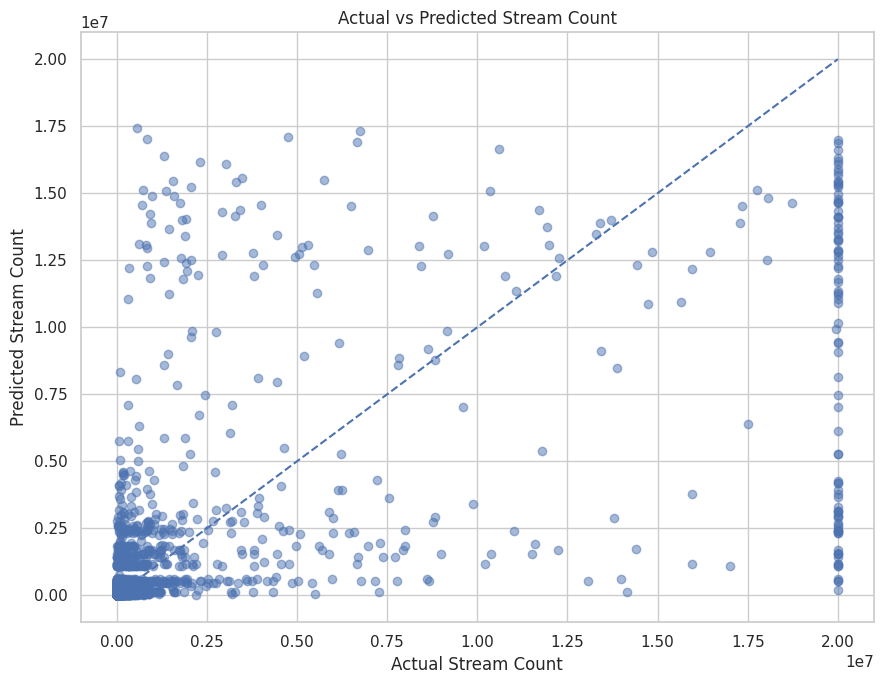


CLASSIFICATION MODEL

Removed high-cardinality columns: ['artist_name', 'album_name']

Class Distribution:
popularity_category
Medium    64111
Low       10861
High      10028
Name: count, dtype: int64

Training samples: 68000
Testing samples : 17000

CLASSIFICATION RESULTS
Accuracy: 91.92 %

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.65      0.78      2006
         Low       1.00      0.71      0.83      2172
      Medium       0.90      1.00      0.95     12822

    accuracy                           0.92     17000
   macro avg       0.96      0.78      0.85     17000
weighted avg       0.93      0.92      0.91     17000



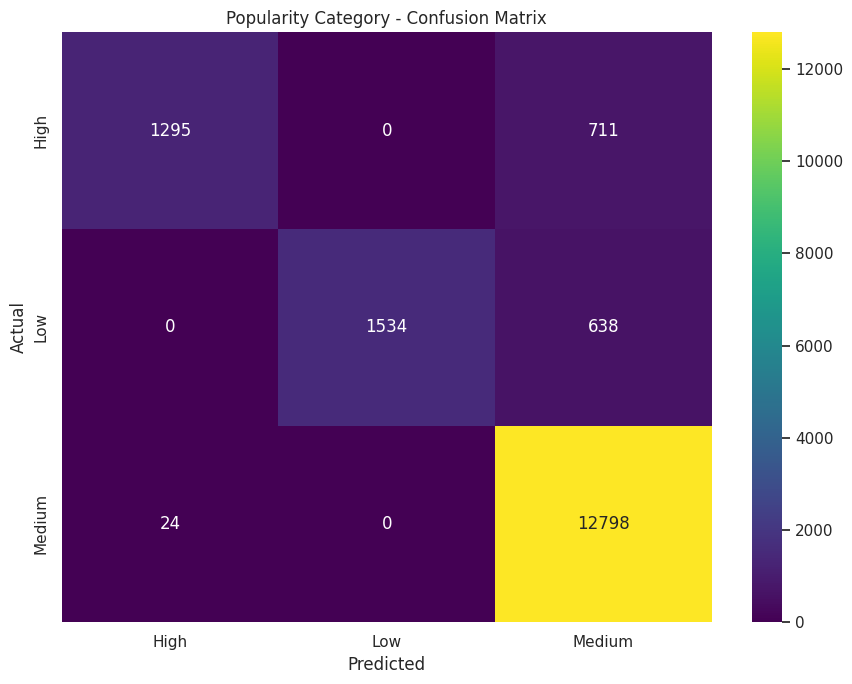


FINAL MODEL SUMMARY
Regression R²       : 0.4316
Regression MAE      : 192192.2846
Regression RMSE     : 1269784.2697
Classification Accuracy : 91.92%


In [11]:
# ============================================================
# MUSIC DATASET
# FEATURE ENGINEERING
# TRAIN / TEST
# REGRESSION + CLASSIFICATION
# ACCURACY + R2
# RANDOM FOREST
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. COPY DATASET
# ============================================================

data = df.copy()

print("=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)

print("Shape:", data.shape)
print(data.head())


# ============================================================
# 2. BASIC CLEANING
# ============================================================

# Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

# Replace infinity values
data.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# ============================================================
# 3. DATE FEATURE ENGINEERING
# ============================================================

if "release_date" in data.columns:

    data["release_date"] = pd.to_datetime(
        data["release_date"],
        errors="coerce"
    )

    data["release_year"] = (
        data["release_date"].dt.year
    )

    data["release_month"] = (
        data["release_date"].dt.month
    )

    data["release_day"] = (
        data["release_date"].dt.day
    )

    data["release_dayofyear"] = (
        data["release_date"].dt.dayofyear
    )

    data["release_week"] = (
        data["release_date"]
        .dt.isocalendar()
        .week
        .astype(float)
    )


# ============================================================
# 4. MUSIC FEATURE ENGINEERING
# ============================================================

# Energy × Danceability
if (
    "energy" in data.columns
    and "danceability" in data.columns
):

    data["energy_danceability"] = (
        data["energy"]
        * data["danceability"]
    )


# Energy × Loudness
if (
    "energy" in data.columns
    and "loudness" in data.columns
):

    data["energy_loudness"] = (
        data["energy"]
        * data["loudness"]
    )


# Tempo category
if "tempo" in data.columns:

    data["tempo_category"] = pd.cut(
        data["tempo"],
        bins=[
            -np.inf,
            80,
            120,
            160,
            np.inf
        ],
        labels=[
            "Slow",
            "Medium",
            "Fast",
            "Very_Fast"
        ]
    )


# Duration category
if "duration_minutes" in data.columns:

    data["duration_category"] = pd.cut(
        data["duration_minutes"],
        bins=[
            -np.inf,
            2,
            3,
            5,
            np.inf
        ],
        labels=[
            "Short",
            "Medium",
            "Long",
            "Very_Long"
        ]
    )


# Artist popularity proxy
if (
    "artist_track_count" in data.columns
    and
    "popularity" in data.columns
):

    data["artist_popularity_interaction"] = (
        data["artist_track_count"]
        * data["popularity"]
    )


# ============================================================
# 5. REGRESSION
# Predict STREAM COUNT
# ============================================================

print("\n" + "=" * 70)
print("REGRESSION MODEL")
print("=" * 70)

reg_target = "stream_count"

# Make target numeric
data[reg_target] = pd.to_numeric(
    data[reg_target],
    errors="coerce"
)

# Remove rows where target is missing
reg_data = data[
    data[reg_target].notna()
].copy()

X_reg = reg_data.drop(
    columns=[reg_target],
    errors="ignore"
)

y_reg = reg_data[reg_target]


# ============================================================
# 6. REMOVE IDENTIFIER / HIGH-CARDINALITY COLUMNS
# ============================================================

remove_columns = [
    "track_id",
    "track_name",
    "canonical_url",
    "release_date",
    "stream_count",
    "log_stream_count",

    # popularity category is derived from popularity
    "popularity_category"
]

X_reg = X_reg.drop(
    columns=[
        col for col in remove_columns
        if col in X_reg.columns
    ],
    errors="ignore"
)


# ============================================================
# 7. REMOVE CONSTANT COLUMNS
# ============================================================

constant_columns = [
    col
    for col in X_reg.columns
    if X_reg[col].nunique(
        dropna=False
    ) <= 1
]

X_reg = X_reg.drop(
    columns=constant_columns
)


# ============================================================
# 8. TRAIN TEST SPLIT - REGRESSION
# ============================================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)

print("\nTraining samples:", len(X_train_reg))
print("Testing samples :", len(X_test_reg))


# ============================================================
# 9. COLUMN TYPES
# ============================================================

numeric_reg = X_train_reg.select_dtypes(
    include=np.number
).columns.tolist()

categorical_reg = X_train_reg.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ============================================================
# 10. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_reg
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_reg
        )
    ]
)


# ============================================================
# 11. RANDOM FOREST REGRESSOR
# ============================================================

regression_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_reg
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=150,
                max_depth=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ============================================================
# 12. TRAIN REGRESSION MODEL
# ============================================================

regression_model.fit(
    X_train_reg,
    y_train_reg
)


# ============================================================
# 13. REGRESSION PREDICTION
# ============================================================

y_pred_reg = regression_model.predict(
    X_test_reg
)


# ============================================================
# 14. REGRESSION METRICS
# ============================================================

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("\n" + "=" * 70)
print("REGRESSION RESULTS")
print("=" * 70)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))


# ============================================================
# 15. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

minimum = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

maximum = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Stream Count")
plt.ylabel("Predicted Stream Count")

plt.title(
    "Actual vs Predicted Stream Count"
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. CLASSIFICATION
# Predict POPULARITY CATEGORY
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION MODEL")
print("=" * 70)

class_target = "popularity_category"

# Remove rows without target
class_data = data[
    data[class_target].notna()
].copy()

X_class = class_data.drop(
    columns=[class_target],
    errors="ignore"
)

y_class = class_data[class_target].astype(str)


# ============================================================
# 17. REMOVE LEAKAGE / IDENTIFIER COLUMNS
# ============================================================

remove_class_columns = [
    "track_id",
    "track_name",
    "canonical_url",
    "release_date",

    # Popularity itself is used to create
    # popularity_category, therefore using it
    # would cause target leakage.
    "popularity",

    # Stream count can strongly leak popularity
    "stream_count",

    "log_stream_count"
]

X_class = X_class.drop(
    columns=[
        col
        for col in remove_class_columns
        if col in X_class.columns
    ],
    errors="ignore"
)


# ============================================================
# 18. REMOVE CONSTANT FEATURES
# ============================================================

constant_class = [
    col
    for col in X_class.columns
    if X_class[col].nunique(
        dropna=False
    ) <= 1
]

X_class = X_class.drop(
    columns=constant_class
)


# ============================================================
# 19. REMOVE VERY HIGH CARDINALITY TEXT COLUMNS
# ============================================================

high_cardinality = []

for col in X_class.select_dtypes(
    include=["object", "category"]
).columns:

    unique_ratio = (
        X_class[col].nunique()
        /
        len(X_class)
    )

    if unique_ratio > 0.50:

        high_cardinality.append(col)

X_class = X_class.drop(
    columns=high_cardinality,
    errors="ignore"
)

print(
    "\nRemoved high-cardinality columns:",
    high_cardinality
)


# ============================================================
# 20. TRAIN TEST SPLIT - CLASSIFICATION
# ============================================================

# Check class counts first
class_counts = y_class.value_counts()

print("\nClass Distribution:")
print(class_counts)

# Keep only classes having at least 2 samples
valid_classes = class_counts[
    class_counts >= 2
].index

valid_rows = y_class.isin(
    valid_classes
)

X_class = X_class.loc[
    valid_rows
].copy()

y_class = y_class.loc[
    valid_rows
].copy()


# ============================================================
# 21. TRAIN TEST SPLIT
# ============================================================

X_train_class, X_test_class, y_train_class, y_test_class = (
    train_test_split(
        X_class,
        y_class,
        test_size=0.20,
        random_state=42,
        stratify=y_class
    )
)

print("\nTraining samples:", len(X_train_class))
print("Testing samples :", len(X_test_class))


# ============================================================
# 22. CLASSIFICATION COLUMN TYPES
# ============================================================

numeric_class = X_train_class.select_dtypes(
    include=np.number
).columns.tolist()

categorical_class = X_train_class.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ============================================================
# 23. CLASSIFICATION PREPROCESSOR
# ============================================================

preprocessor_class = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_class
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_class
        )
    ]
)


# ============================================================
# 24. RANDOM FOREST CLASSIFIER
# ============================================================

classification_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_class
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=20,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)


# ============================================================
# 25. TRAIN CLASSIFICATION MODEL
# ============================================================

classification_model.fit(
    X_train_class,
    y_train_class
)


# ============================================================
# 26. CLASSIFICATION PREDICTION
# ============================================================

y_pred_class = classification_model.predict(
    X_test_class
)


# ============================================================
# 27. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

print("\n" + "=" * 70)
print("CLASSIFICATION RESULTS")
print("=" * 70)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 28. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test_class,
        y_pred_class,
        zero_division=0
    )
)


# ============================================================
# 29. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_class,
    y_pred_class,
    labels=classification_model
    .named_steps["model"]
    .classes_
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=classification_model
    .named_steps["model"]
    .classes_,
    yticklabels=classification_model
    .named_steps["model"]
    .classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Popularity Category - Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    f"Regression R²       : {r2:.4f}"
)

print(
    f"Regression MAE      : {mae:.4f}"
)

print(
    f"Regression RMSE     : {rmse:.4f}"
)

print(
    f"Classification Accuracy : "
    f"{accuracy * 100:.2f}%"
)

## Thanks......Please Upvote